In [1]:
from swemnics.problems import SlopedBeachProblem
from swemnics import solvers as Solvers
from mpi4py import MPI
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dolfinx import fem as fe
import pickle
import os
import pickle
import numpy as np
from itertools import product
import time
import pandas as pd
import seaborn as sns

from dca_utils import*
from metrics import calculate_analysis_metrics
from observation_operator import build_observation_matrix
from data_io import save_pickle, load_pickle
from fourd_var import run_assimilation, setup_data_assimilation, run_data_assimilation
from plotting import plot_mixed_function, plot_comparison1, plot_comparison2


sns.set_palette("bright")
plt.style.use("mystyle1.mplstyle")


In [1]:
# check dolfinx version
import dolfinx
print("Dolfinx version:", dolfinx.__version__)

Dolfinx version: 0.9.0


In [2]:
comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

final_time = Time.SEVEN_DAYS.seconds   # 7 days in seconds
window_size = Time.ONE_HOUR.seconds

dt = 600  # 30 minutes in seconds
problem_params = {
    'dt': dt,
    't': 0,
    't_final': final_time,
    'num_steps': int(np.ceil(final_time/dt)),
    'num_windows': final_time//window_size,  # divide by 4 hours in seconds = 42 windows
    'fric_law': 'linear',    #friction law either quadratic or linear
    'alpha': 2.0 * np.pi / Time.TWELVE_HOURS.seconds,  # 2.5 cycles per 12 hours
    'sol_var': 'h'             #solution variable either h or hu
}

solver_params = {"rtol": 1e-5,
          "atol": 1e-6,
          "max_it":10,
          "relaxation_parameter":1.0,
          "ksp_type": "gmres",
          "pc_type": "ilu",
          "ksp_ErrorIfNotConverged": False
          }#,"pc_factor_mat_solver_type":"mumps"}


prob, solver = create_problem_solver(problem_params, "sloped_beach", true_signal=True, verbose=True)

SWE TYPE full
Wetting drying activated 

Location of shoreline: 13800
setting initial condition
Fully conservative flux
Fully conservative flux
WD nonspherical

CF =  0.025
Adding DG boundary conditions weakly
Fully conservative flux


In [3]:
run_true = False   # Set to True to run the true solver and generate the true signal

if run_true:
    assert problem_params['num_steps'] == int(np.ceil(problem_params['t_final']/problem_params['dt']))
    true_solver = get_true_signal(solver,'sloped_beach', solver_params,1)
    true_signal = np.array(true_solver.saved_states)

In [105]:


stat_ids1 = np.arange(1, 20, 2).tolist() + np.arange(103,129,2).tolist()
stat_ids1.sort()

config_indices1 = {
    'method': 'indices', 
    'params': stat_ids1
}
H1, obs_stations1, obs_spatial_indices1 = build_observation_matrix(prob, prob.V, config_indices1)

stat_ids2 = {
    'method': 'region', 
    'params': {
        'bounds': {'x': (3000, 9000.0), 'y': (1000, 6000)},
        'criteria': 'center'
    }
}

H2, obs_stations2, obs_spatial_indices2 = build_observation_matrix(prob, prob.V, stat_ids2)

Selected 23 stations using method 'indices'
Station cells: [  1   3   5   7   9  11  13  15  17  19 103 105 107 109 111 113 115 117
 119 121 123 125 127]
Selected 44 stations using method 'region'
Station cells: [ 31  37  43  44  49  50  55  56  57  61  62  63  67  68  69  70  73  74
  75  76  79  80  81  82  85  86  87  88  91  92  93  94  98  99 100 104
 105 106 111 112 116 117 122 126]


Plot saved to: figures/beachtrue.png


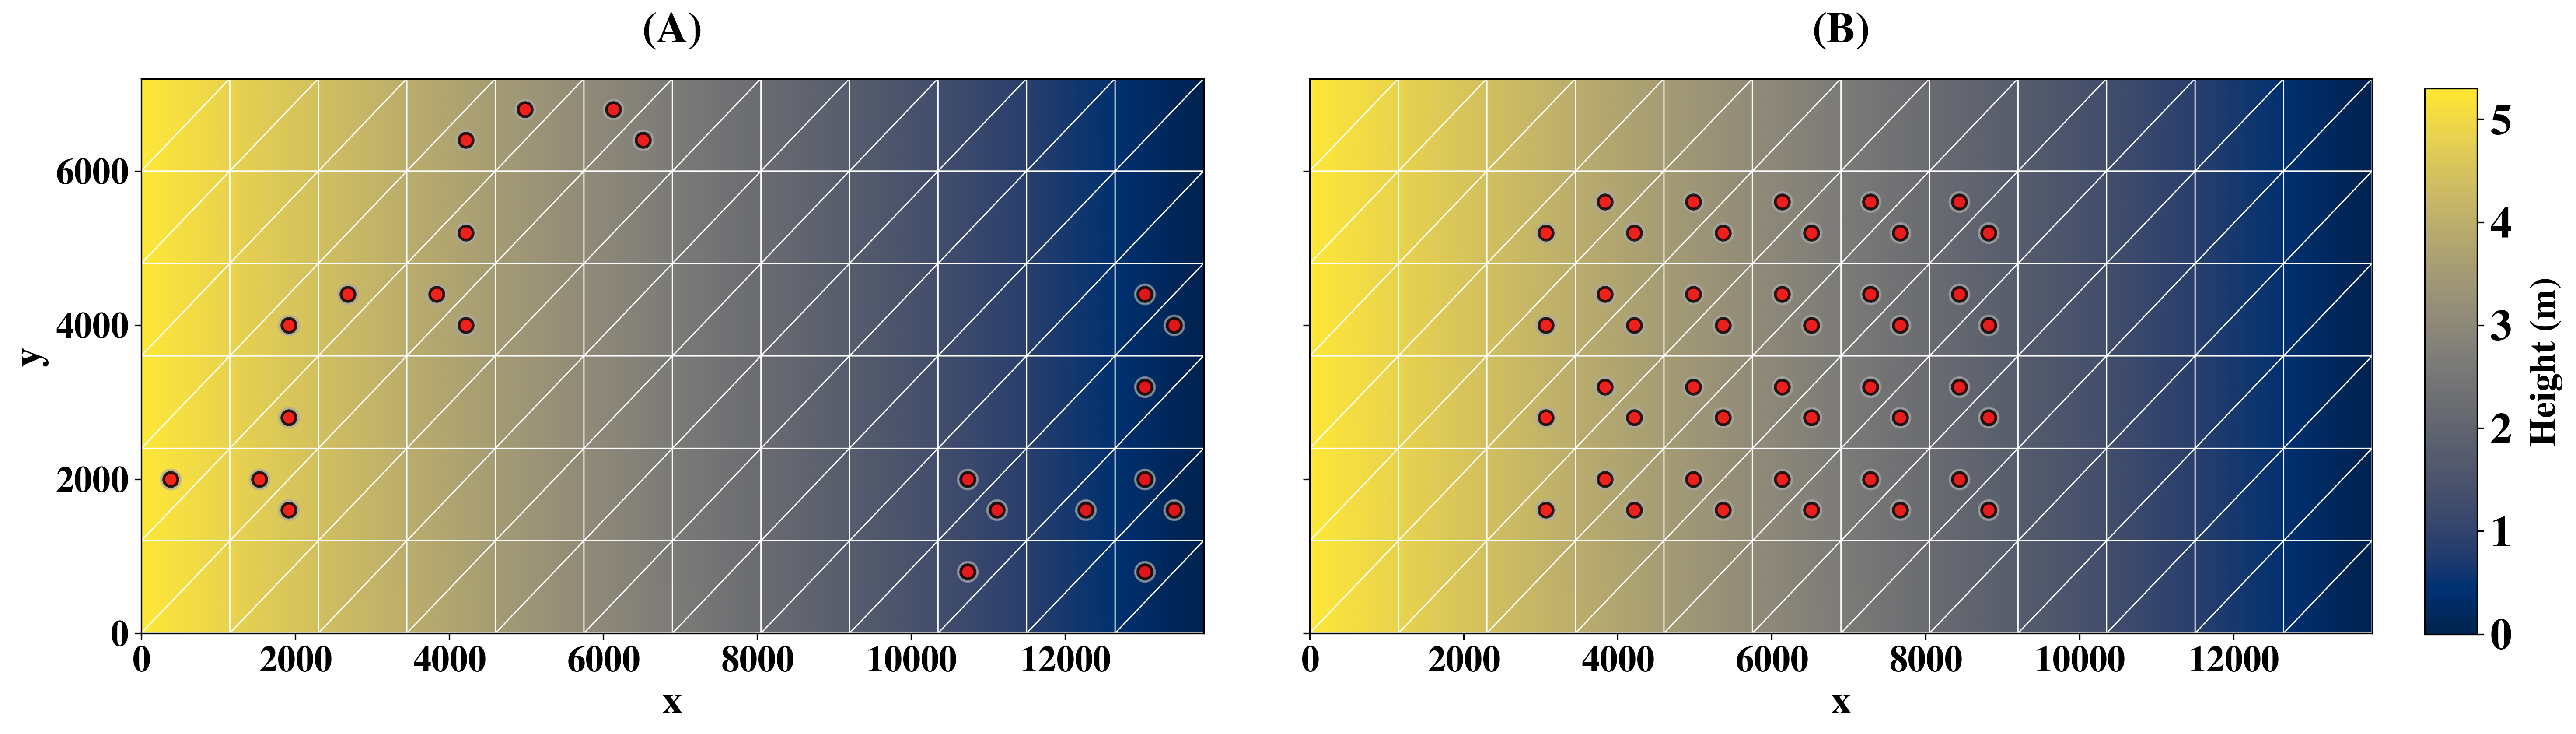

In [106]:
result = load_pickle('setup_result.pkl')
true_signal = load_pickle('true_signal.pkl')


plot_mixed_function_dual(prob.mesh,
                    prob.V,
                    true_signal[0],
                    stations_1=obs_stations1,
                    stations_2=obs_stations2,
                    station_ids_1=None,
                    station_ids_2=None,
                    save_path='figures/beachtrue.png')

In [100]:
# station_ids = {
#     'method': 'region', 
#     'params': {
#         'bounds': {'x': (3000, 9000.0), 'y': (1000, 6000)},
#         'criteria': 'center'
#     }
# }
# H, obs_stations, obs_spatial_indices = build_observation_matrix(prob, prob.V, station_ids)


# # result = load_pickle('setup_result.pkl')
# true_signal = load_pickle('true_signal.pkl')

    
# plot_mixed_function(prob.mesh,
#                     prob.V,
#                     true_signal[0],
#                     stations=obs_stations,
#                     station_style='halo',
#                     save_path='figures/sloped_beach_true_signal_2.png')

____

In [ ]:
# Linear Friction True Signal Case: 
analysis_types = ['bayes','dci', 'dci_wme']  # Include both analysis types
final_time = Time.SEVEN_DAYS.seconds  # 3 days in seconds (see dca_utils to see how Time works)
window_size = Time.ONE_HOUR.seconds
inflation_factor = 4.0
obs_std = 1.5

# # observation stations
# stat_ids = np.arange(1, 20, 2).tolist() + np.arange(103,129,2).tolist()
# stat_ids.sort()

# station_ids = {
#     'method': 'indices', 
#     'params': stat_ids
# }

station_ids = {
    'method': 'region', 
    'params': {
        'bounds': {'x': (3000, 9000.0), 'y': (1000, 6000)},
        'criteria': 'center'
    }
}
    
da_results = run_data_assimilation(analysis_types = analysis_types,
                                run_true_signal=False,
                                obs_std=obs_std,
                                inflation_factor=inflation_factor,
                                window_size=window_size,
                                final_time=final_time,
                                station_ids = station_ids,
                                obs_time_freq=1,  # How many model time steps between observations
                                obs_space_freq=2, # this parameter is no longer used, just here for backwards compatibility
                                friction_type="linear" # this is the true friction, Experiment friction is mannings
                                )

In [60]:
# # Case 1: DCI Analysis 
dci_rmse, dci_misfit = calculate_analysis_metrics(
    analysis_name="dci",
)

# Case 2: Bayes Analysis 
bayes_rmse, bayes_misfit = calculate_analysis_metrics(
    analysis_name="bayes",
)

# # Case 3: DCI WME Analysis 
wme_rmse, wme_misfit = calculate_analysis_metrics(
    analysis_name="dci_wme",
)

DCI RMSE: 0.2528222975, DCI, Relative Misfit: 0.1156
BAYES RMSE: 0.2528279728, BAYES, Relative Misfit: 0.1156
DCI_WME RMSE: 0.2528125626, DCI_WME, Relative Misfit: 0.1156


In [14]:
# # Case 1: DCI Analysis 
dci_rmse, dci_misfit = calculate_analysis_metrics(
    analysis_name="dci",
)

# Case 2: Bayes Analysis 
bayes_rmse, bayes_misfit = calculate_analysis_metrics(
    analysis_name="bayes",
)

# # Case 3: DCI WME Analysis 
wme_rmse, wme_misfit = calculate_analysis_metrics(
    analysis_name="dci_wme",
)

DCI RMSE: 0.2528100621, DCI, Relative Misfit: 0.1100
BAYES RMSE: 0.2528213509, BAYES, Relative Misfit: 0.1100
DCI_WME RMSE: 0.2528018090, DCI_WME, Relative Misfit: 0.1100


In [24]:
bayes_analysis.shape, dci_wme_analysis.shape, dci_analysis.shape, true_signal.shape

((1009, 1296), (433, 1296), (433, 1296), (433, 1296))

In [61]:
true_signal = load_pickle('true_signal.pkl')
bayes_analysis = load_pickle('bayes_analysis.pkl')
dci_analysis = load_pickle('dci_analysis.pkl')
dci_wme_analysis = load_pickle('dci_wme_analysis.pkl')

# need H from experiment setup for data misfit calculation
result = load_pickle('setup_result.pkl')

metrics = compute_daily_metrics(
    true_signal,
    bayes_analysis, 
    dci_analysis, 
    dci_wme_analysis,
    result,
    num_days=7
)

df, latex_str = create_analysis_table(
    metrics, 
    num_days=7,
    output_file='custom_analysis.tex',
    save_csv=True,
    save_pickle=True,
    method_names={
        'bayes': 'Bayesian 4D-Var',
        'dci': 'DCI Method', 
        'dci_wme': 'DCI-WME Method'
    },
    float_format="{:.4f}",
    caption='Custom Analysis Results',
    label='tab:custom_results'
)

true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296), analysis.shape: (1296,)
true_signal.shape: (1009, 1296)

In [11]:
df

Bayesian 4D-Var             DCI Method             DCI-WME Method  \
                 RMSE Data Misfit       RMSE Data Misfit           RMSE   
Day                                                                       
1            0.291664    0.058380   0.291657    0.058356       0.291664   
2            0.362816    0.078720   0.362814    0.078711       0.362816   
3            0.390772    0.133971   0.391642    0.133972       0.390772   
Total        0.563529    0.273192   0.563531    0.273192       0.563529   

                   
      Data Misfit  
Day                
1        0.058380  
2        0.078720  
3        0.133971  
Total    0.273192

In [62]:
V_sub = prob.V.sub(0)
V_sub_c, sub_map = V_sub.collapse()

true_signal = load_pickle('true_signal.pkl')[:,sub_map]
bayes_analysis = load_pickle('bayes_analysis.pkl')[:,sub_map]
dci_analysis = load_pickle('dci_analysis.pkl')[:,sub_map]
dci_wme_analysis = load_pickle('dci_wme_analysis.pkl')[:,sub_map]
saved_true_bathy = load_pickle('true_bathy.pkl')
saved_bathy = load_pickle('da_bathy.pkl')

In [55]:

# from dolfinx import fem as fe
from matplotlib import gridspec
import matplotlib.patheffects as path_effects
import seaborn as sns

from matplotlib.tri import Triangulation
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def plot_comparison1(
    msh,
    V,
    plot_triplets,
    component=0,
    titles=None,
    stations=None,
    cmap="viridis",
    diff_cmap="seismic",
    selected_days=None,
    save_path=None,
    dpi=300,
    format="png",
    show=True,
):
    from dolfinx.fem import Function

    if selected_days is None:
        filtered_triplets = plot_triplets
        day_labels = list(range(1, len(plot_triplets) + 1))
    else:
        selected_days = list(selected_days)
        filtered_triplets = []
        day_labels = []
        for day_num in selected_days:
            if 1 <= day_num <= len(plot_triplets):
                filtered_triplets.append(plot_triplets[day_num - 1])
                day_labels.append(day_num)
            else:
                print(
                    f"Warning: Day {day_num} is out of range (available days: 1-{len(plot_triplets)})"
                )

    if not filtered_triplets:
        raise ValueError("No valid days selected for plotting")

    # Compute symmetric global color scale limits
    all_values = np.concatenate(
        [np.abs(arr).flatten() for triplet in filtered_triplets for arr in triplet]
    )
    vmax = np.max(all_values)
    vmin = -vmax

    coords = msh.geometry.x[:, :2]
    tdim = msh.topology.dim
    msh.topology.create_connectivity(tdim, 0)
    cells = msh.topology.connectivity(tdim, 0).array.reshape(-1, 3)
    triang = Triangulation(coords[:, 0], coords[:, 1], cells)

    n_rows = len(filtered_triplets)
    fig, axes = plt.subplots(
        n_rows, 3, figsize=(15, 2.8 * n_rows), sharex=True, sharey=True
    )

    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    tpc_diff = None

    for i, (diff1_arr, diff2_arr, diff3_arr) in enumerate(filtered_triplets):
        for j, u_array in enumerate([diff1_arr, diff2_arr, diff3_arr]):
            ax = axes[i, j]
            V_sub = V.sub(component)
            V_sub_c, sub_map = V_sub.collapse()
            u_sub = Function(V_sub_c)
            u_sub.x.array[:] = u_array
            dof_coords = V_sub_c.tabulate_dof_coordinates()[:, :2]
            dof_to_vertex_map = np.array(
                [np.argmin(np.linalg.norm(dof_coords - x, axis=1)) for x in coords]
            )
            values_at_vertices = u_sub.x.array[dof_to_vertex_map]

            tpc = ax.tripcolor(
                triang,
                values_at_vertices,
                shading="gouraud",
                cmap=diff_cmap,
                vmin=vmin,
                vmax=vmax,
            )
            tpc_diff = tpc

            ax.triplot(triang, color="k", linewidth=0.3, alpha=0.5)
            ax.set_aspect("equal")
            ax.margins(0)
            ax.set_xlim(coords[:, 0].min(), coords[:, 0].max())
            ax.set_ylim(coords[:, 1].min(), coords[:, 1].max())

            if i == n_rows - 1:
                ax.set_xlabel("x")
            if j == 0:
                ax.set_ylabel("y", fontsize=20)
            if i == 0:
                labels = ["4D-Var", "DC 4D-Var", "DC-WME 4D-Var"]
                ax.set_title(labels[j])

            if stations is not None:
                stations = np.asarray(stations)
                if stations.shape[1] == 3:
                    stations = stations[:, :2]
                ax.plot(stations[:, 0], stations[:, 1], "ro", markersize=5)

    plt.subplots_adjust(hspace=0.02, wspace=0.1, bottom=0.07, left=0.1, top=0.98)

    for i in range(n_rows):
        ax_pos = axes[i, 0].get_position()
        row_center = ax_pos.y0 + ax_pos.height / 2
        actual_day = day_labels[i]
        fig.text(
            0.02,
            row_center,
            f"Day {actual_day}",
            rotation=90,
            fontsize=22,
            ha="center",
            va="center",
            weight="bold",
        )

    cbar_ax = fig.add_axes([0.25, -0.2, 0.5, 0.08])
    fig.colorbar(tpc_diff, cax=cbar_ax, orientation="horizontal").set_label(
        "Difference (m)", fontsize=16
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, format=format, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")

    if show:
        plt.show()

Figure saved to: figures/sloped_beach_comparison_2.png


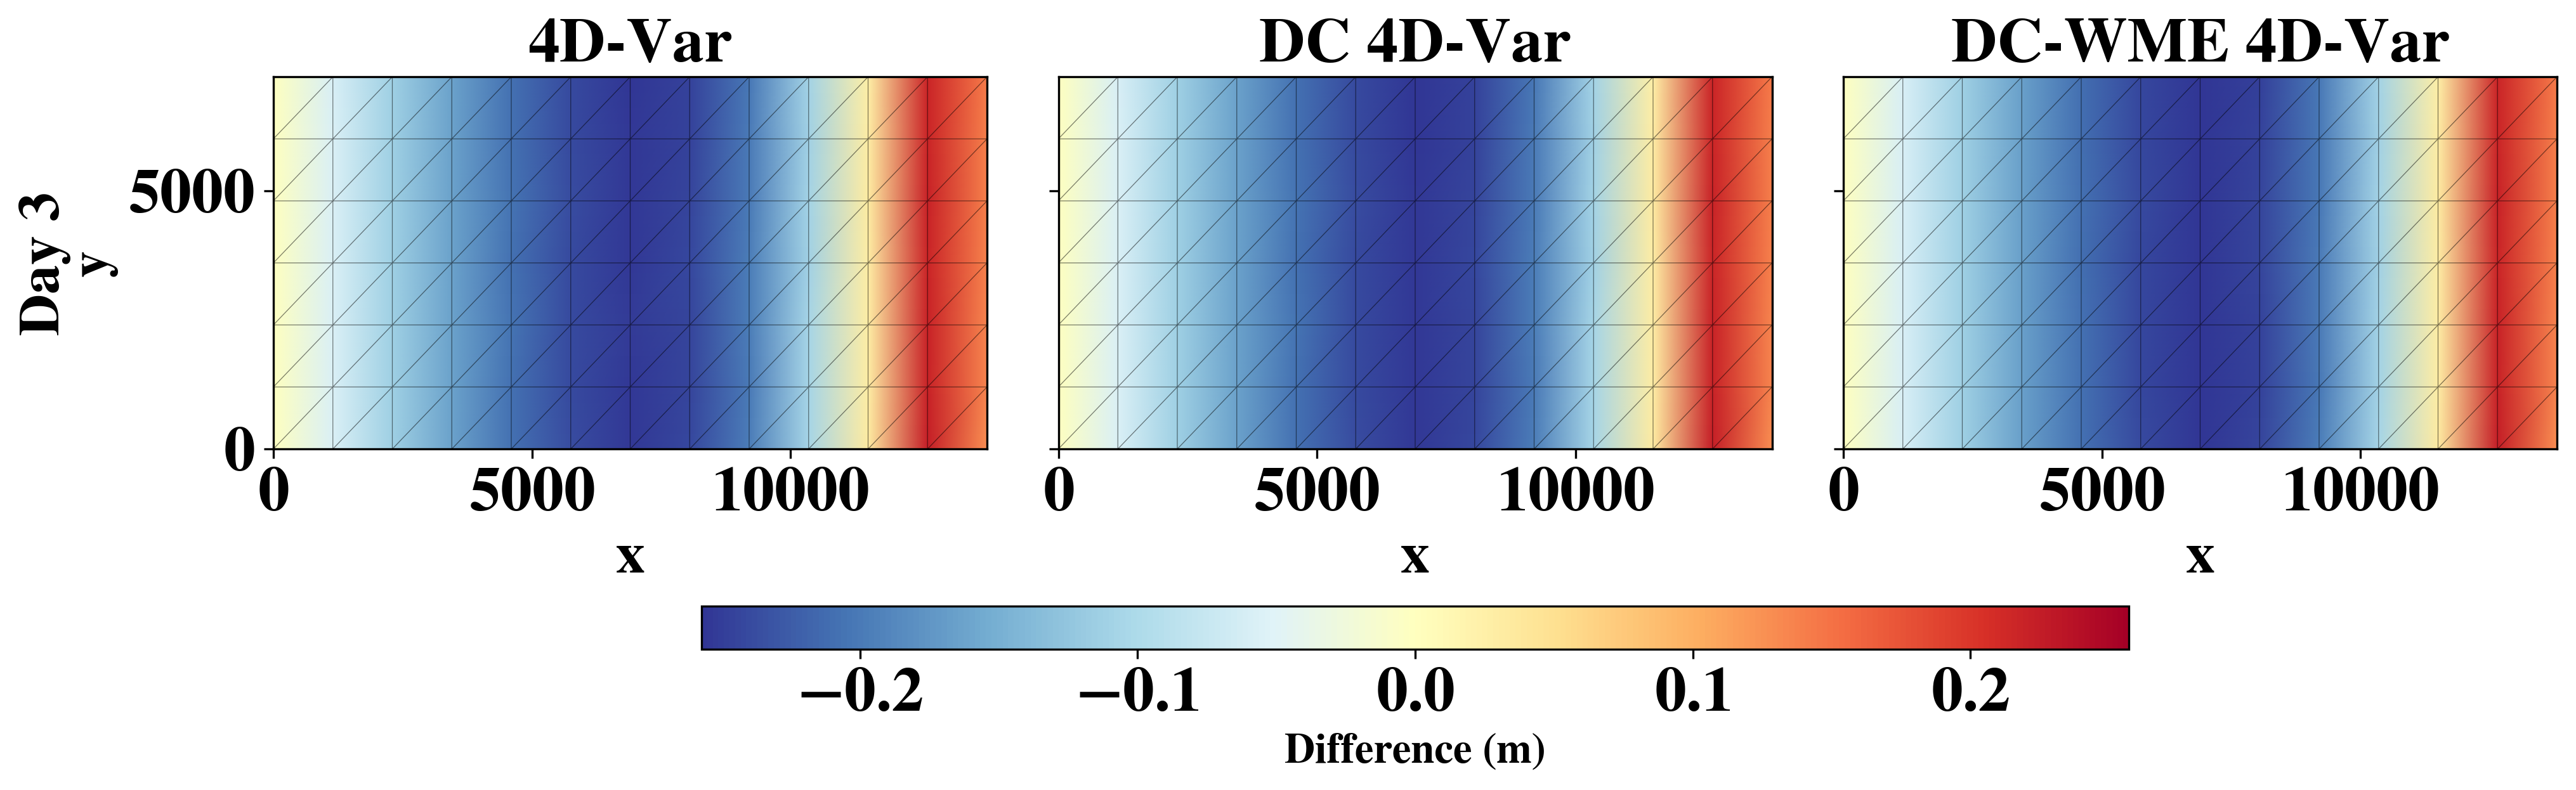

In [63]:
true_signal, bayes_analysis, dci_analysis, dci_wme_analysis, plot_triplets_1 = prepare_analysis_data(
    true_signal, bayes_analysis, dci_analysis, dci_wme_analysis,
    saved_bathy, saved_true_bathy, num_days=7
)


plot_comparison1(prob.mesh,
                prob.V,
                plot_triplets_1,
                component=0,
                titles=None,
                stations=None,
                cmap='cividis',
                diff_cmap='RdYlBu_r',
                selected_days=[3],
                save_path='figures/sloped_beach_comparison_2.png',
                dpi=300,
                format='png',
                show=True,
)

Figure saved to: figures/plot_comparison2.png


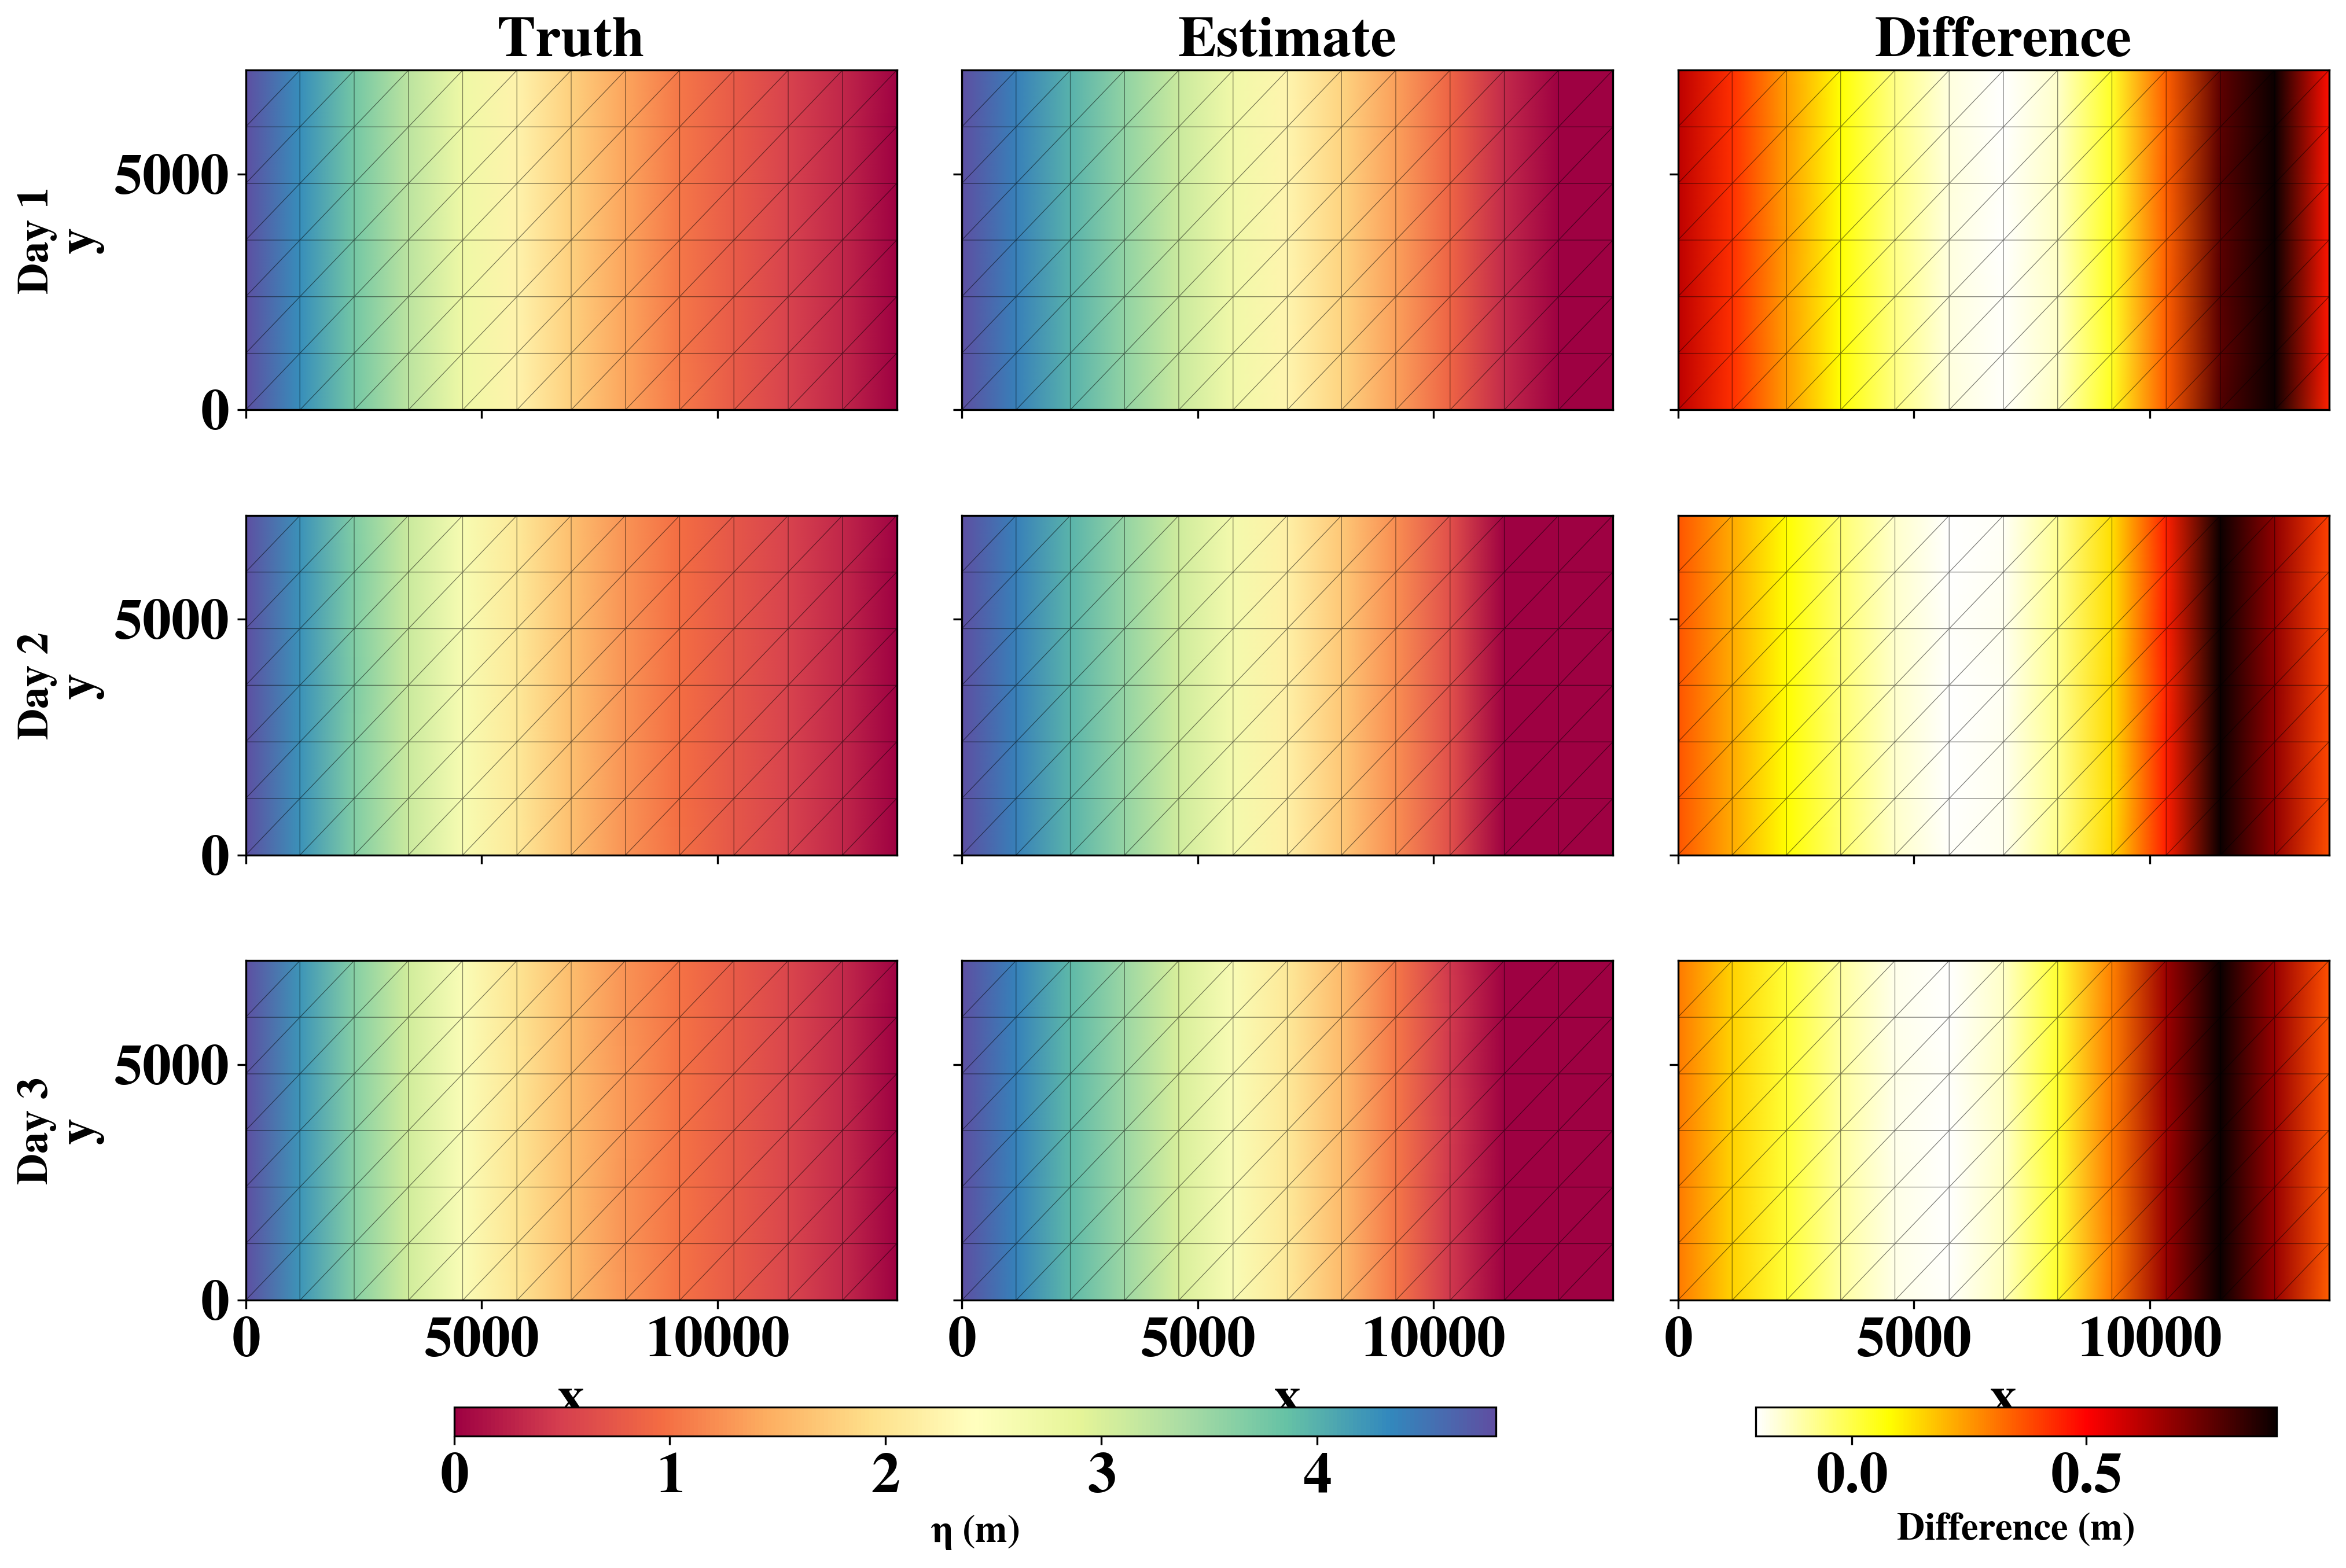

In [32]:
V_sub = prob.V.sub(0)
V_sub_c, sub_map = V_sub.collapse()

true_signal = load_pickle('true_signal.pkl')[:,sub_map]
dci_wme_analysis = load_pickle('dci_wme_analysis.pkl')[:,sub_map]
saved_true_bathy = load_pickle('true_bathy.pkl')
saved_bathy = load_pickle('da_bathy.pkl')
# true_signal = true_signal - saved_true_bathy
# dci_wme_analysis = dci_wme_analysis - saved_bathy

plot_triplets_2 = create_plot_triplets(true_signal, dci_wme_analysis, num_days=3)


plot_comparison2(prob.mesh,
                prob.V,
                plot_triplets_2,
                component=0,
                titles=None,
                stations=None,
                cmap='Spectral',
                diff_cmap='hot_r',
                save_path='figures/plot_comparison2.png',
                dpi=300,
                format='png',
                show=True)